# National Level Model — Data Preparation, SARIMAX and XGBoost

This notebook implements the national-level modeling pipeline described in Plan A:

1. **Data merging** — load and join all six source files on the `time` column
2. **SARIMAX** — parametric baseline with explicit seasonal and serial structure
3. **XGBoost** — nonlinear ML complement with SHAP-based interpretation

The merged dataset covers **2016-07 to 2025-12** (114 months), determined by the shortest series (Realtor.com new listing count starting July 2016). The train/test split is applied after merging and is shared identically across both models to ensure fair comparison.

## Import packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import shap

print("All imports successful.")
print(f"pandas  : {pd.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"shap    : {shap.__version__}")

All imports successful.
pandas  : 2.0.3
xgboost : 3.2.0
shap    : 0.48.0


f:\Miniconda3\envs\pydata\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import and Merge Datasets

Each file is loaded, the `time` column is parsed to a `datetime` period, and all six frames are inner-joined on `time`. This preserves only rows where every variable has an observed value.

**Overlap window:** 2016-07 to 2025-12 (114 months), driven by the Realtor.com new listing series which starts July 2016.

**Key decisions:**
- HPI: use the **non-seasonally adjusted** index (`index_nsa`) — seasonal house price variation is substantively relevant to listing decisions and is not duplicated by the SARIMA seasonal component, which captures the seasonal pattern in $Y_t$ net of all regressors
- Mortgage rate premium $L_t$: constructed as `mortgage30us_avg` minus `treasury_10y`
- Unemployment: keep only `unemployment_rate` from the aggregated state file
- Permits: keep `permits_count` as the supply control $S_t$

In [2]:
# ── File paths ────────────────────────────────────────────────────────────
PATH_TREASURY  = "../../data/national/national_10y_treasury_monthly.csv"
PATH_MORTGAGE  = "../../data/national/national_30y_mortgage_monthly.csv"
PATH_HPI       = "../../data/national/national_house_price_index_monthly.csv"
PATH_LISTING   = "../../data/national/national_new_listing_count_monthly.csv"
PATH_PERMITS   = "../../data/national/national_permits_count_monthly.csv"
PATH_UNEMP     = "../../data/national/national_unemployment_aggregated_from_states_unadjusted.csv"

def load(path, usecols=None):
    df = pd.read_csv(path, usecols=usecols)
    df["time"] = pd.to_datetime(df["time"], format="%Y-%m")
    return df.set_index("time").sort_index()

# ── Load each file ─────────────────────────────────────────────────────────
treasury = load(PATH_TREASURY)                          # treasury_10y
mortgage = load(PATH_MORTGAGE, usecols=["time","mortgage30us_avg"])
hpi      = load(PATH_HPI,      usecols=["time","index_nsa"])
listing  = load(PATH_LISTING)                           # new_listing_count
permits  = load(PATH_PERMITS)                           # permits_count
unemp    = load(PATH_UNEMP,    usecols=["time","unemployment_rate"])

# ── Inner join on time index ───────────────────────────────────────────────
df = (listing
      .join(mortgage,  how="inner")
      .join(treasury,  how="inner")
      .join(unemp,     how="inner")
      .join(hpi,       how="inner")
      .join(permits,   how="inner"))

# ── Construct mortgage rate premium L_t = mortgage30 - treasury_10y ───────
df["lock_in_premium"] = df["mortgage30us_avg"] - df["treasury_10y"]

# ── Rename for clarity ─────────────────────────────────────────────────────
df = df.rename(columns={
    "new_listing_count"  : "Y",
    "lock_in_premium"    : "L",
    "unemployment_rate"  : "U",
    "index_nsa"          : "H",
    "permits_count"      : "S",
    "mortgage30us_avg"   : "mortgage30",
    "treasury_10y"       : "treasury10y",
})

# ── Drop raw rate columns (kept above for reference) ──────────────────────
df = df[["Y", "L", "U", "H", "S", "mortgage30", "treasury10y"]]

print(f"Merged dataset: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Date range    : {df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')}")
print()
print(df.head())
print()
print(df.describe().round(3))

Merged dataset: 113 rows x 7 cols
Date range    : 2016-07 to 2025-12

                   Y      L         U       H      S  mortgage30  treasury10y
time                                                                         
2016-07-01  527576.0  1.940  5.144006  232.83   97.9       3.440         1.50
2016-08-01  470786.0  1.875  5.003441  232.77  111.6       3.435         1.56
2016-09-01  452994.0  1.830  4.795543  232.79  111.7       3.460         1.63
2016-10-01  413380.0  1.710  4.661168  232.76  104.0       3.470         1.76
2016-11-01  376706.0  1.630  4.430212  232.89   94.5       3.770         2.14

                Y        L        U        H        S  mortgage30  treasury10y
count     113.000  113.000  113.000  113.000  113.000     113.000      113.000
mean   419611.982    2.077    4.567  333.677  121.948       4.807        2.731
std     84619.893    0.470    1.765   74.630   17.903       1.506        1.186
min    215940.000    1.342    3.097  232.190   86.900       2.684  

## Train / Test Split

The split is **chronological** — future observations are never used in training. The cutoff is set at **80% of the full sample**, which gives approximately 91 training months and 23 test months.

The same `train` and `test` DataFrames are reused by both the SARIMAX and XGBoost models to ensure a direct and fair RMSE/MAE comparison.

In [3]:
TRAIN_RATIO = 0.80

n_total = len(df)
n_train = int(n_total * TRAIN_RATIO)
n_test  = n_total - n_train

train = df.iloc[:n_train].copy()
test  = df.iloc[n_train:].copy()

split_date = test.index[0].strftime("%Y-%m")

print(f"Total observations : {n_total}")
print(f"Training set       : {n_train} months  "
      f"({train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')})")
print(f"Test set           : {n_test}  months  "
      f"({test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')})")
print(f"Split date (first test month) : {split_date}")

Total observations : 113
Training set       : 90 months  (2016-07 to 2023-12)
Test set           : 23  months  (2024-01 to 2025-12)
Split date (first test month) : 2024-01


## Stationarity Tests

Before fitting SARIMAX, every variable is tested for a unit root using the **Augmented Dickey-Fuller (ADF)** test, confirmed by the **KPSS** test. The differencing orders $d$ and $D$ are determined from these results.

Rules applied:
- ADF p-value < 0.05 **and** KPSS p-value > 0.05 → stationary, no differencing needed
- Otherwise → apply first differencing and re-test

$Y_t$ (new listing count) requires a stationarity decision for the ARIMA component. Each exogenous regressor is also tested and entered in its stationary form — level if already stationary, first difference otherwise. Centering is applied after the stationarity transformation. The re-tests for the differenced regressors are conducted in the SARIMAX Data Preparation block.

In [4]:
import warnings
# warnings.filterwarnings("ignore")
warnings.resetwarnings()
warnings.simplefilter("ignore")

def adf_kpss(series, name):
    adf_stat, adf_p, *_ = adfuller(series.dropna(), autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series.dropna(), regression="c", nlags="auto")
    except Exception:
        kpss_p = np.nan
    stationary = (adf_p < 0.05) and (kpss_p > 0.05 if not np.isnan(kpss_p) else True)
    print(f"  {name:<22} ADF p={adf_p:.4f}  KPSS p={kpss_p:.4f}  "
          f"-> {'STATIONARY' if stationary else 'NON-STATIONARY'}")
    return stationary

print("Stationarity tests on training set (levels):")
for col in ["Y", "L", "U", "H", "S"]:
    adf_kpss(train[col], col)

print()
print("Stationarity tests on first differences of Y:")
adf_kpss(train["Y"].diff().dropna(), "dY (d=1)")

Stationarity tests on training set (levels):
  Y                      ADF p=0.9849  KPSS p=0.0399  -> NON-STATIONARY
  L                      ADF p=0.7491  KPSS p=0.0100  -> NON-STATIONARY
  U                      ADF p=0.0318  KPSS p=0.1000  -> STATIONARY
  H                      ADF p=0.9689  KPSS p=0.0100  -> NON-STATIONARY
  S                      ADF p=0.5977  KPSS p=0.0100  -> NON-STATIONARY

Stationarity tests on first differences of Y:
  dY (d=1)               ADF p=0.0018  KPSS p=0.1000  -> STATIONARY


True

## ACF and PACF Plots

Plot the ACF and PACF of the differenced outcome $\Delta Y_t$ to guide selection of the non-seasonal $(p, q)$ and seasonal $(P, Q)_{12}$ orders.

**Reading guide:**
- Non-seasonal lags 1–11: determine $p$ (PACF cuts off) or $q$ (ACF cuts off)
- Seasonal lags 12, 24, 36: determine $P$ (PACF cuts off) or $Q$ (ACF cuts off)

**Conclusion from plots:** Inspect the output above before running the model grid. Note the lag at which the PACF first cuts off (guides $p$), whether the ACF decays slowly or cuts off (guides $q$), and whether significant spikes appear at lags 12 and 24 (guides $P$ and $Q$). The candidate order list in the next block is designed to span the plausible range suggested by these patterns.

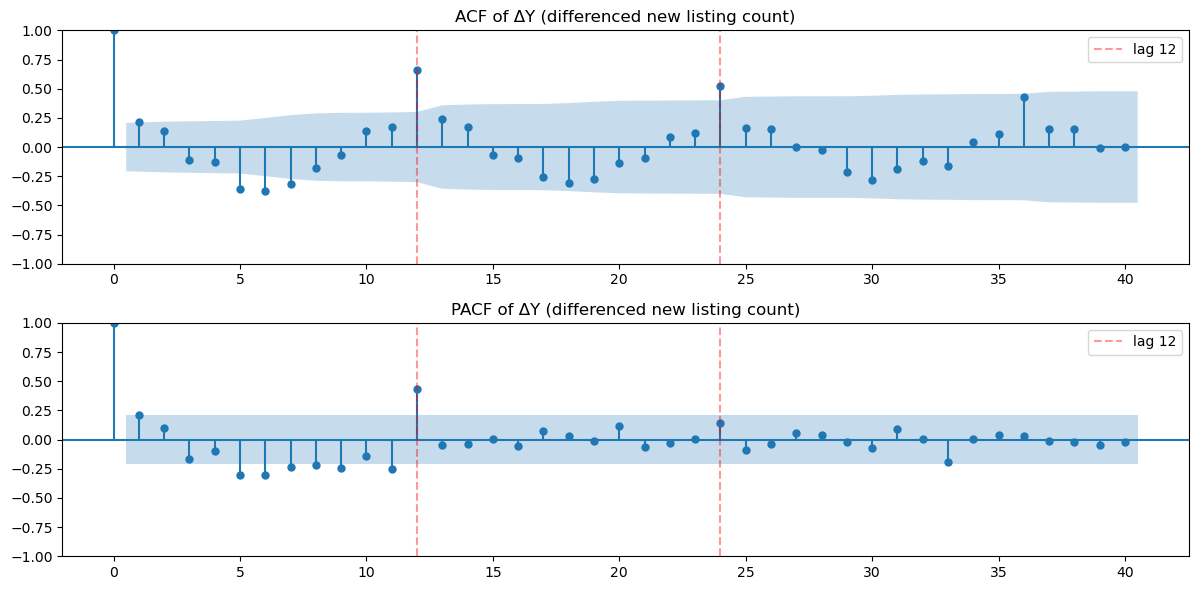

ACF/PACF plot saved.


In [5]:
dY_train = train["Y"].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf( dY_train, lags=40, ax=axes[0], title="ACF of ΔY (differenced new listing count)")
plot_pacf(dY_train, lags=40, ax=axes[1], title="PACF of ΔY (differenced new listing count)", method="ywm")
for ax in axes:
    ax.axvline(x=12, color="red", linestyle="--", alpha=0.4, label="lag 12")
    ax.axvline(x=24, color="red", linestyle="--", alpha=0.4)
    ax.legend()
plt.tight_layout()
plt.savefig("acf_pacf_dY.png", dpi=120, bbox_inches="tight")
plt.show()
print("ACF/PACF plot saved.")

## SARIMAX Data Preparation

Prepare the exogenous regressor matrix for SARIMAX. Each variable is entered in its stationary form, consistent with the stationarity results above:

- $\widetilde{\Delta L}_t = \Delta L_t - \overline{\Delta L}$: first difference of $L_t$, centered on its training-window mean — $L_t$ is non-stationary in levels
- $\tilde{U}_t = U_t - \bar{U}$: $U_t$ in levels, centered on its training-window mean — $U_t$ is stationary in levels
- $\Delta H_t$, $\Delta S_t$: first differences of $H_t$ and $S_t$ — entered in differenced form; not centered as they do not enter any interaction term
- $\widetilde{\Delta L}_t \times \tilde{U}_t$: interaction term

All centering constants are computed on the **training window only** and applied mechanically to the test set to prevent data leakage. The full exog block is $[\widetilde{\Delta L}_t,\; \tilde{U}_t,\; \Delta H_t,\; \Delta S_t,\; \widetilde{\Delta L}_t \times \tilde{U}_t]$.

In [6]:
# ── Compute centering constants from training set only ─────────────────────
U_mean  = train["U"].mean()
dL_mean = train["L"].diff().dropna().mean()

def make_exog(df_in, U_mean, dL_mean):
    exog = pd.DataFrame(index=df_in.index)

    dL = df_in["L"].diff()                    # temporary, not kept as a column
    exog["dL_c"] = dL - dL_mean              # centered differenced L
    exog["U_c"]  = df_in["U"] - U_mean       # U in levels, centered
    exog["dH"]   = df_in["H"].diff()
    exog["dS"]   = df_in["S"].diff()
    exog["LxU"]  = exog["dL_c"] * exog["U_c"]

    return exog.dropna()

exog_train = make_exog(train, U_mean, dL_mean)
exog_test  = make_exog(test,  U_mean, dL_mean)

# ── Stationarity re-tests on transformed regressors (training set) ─────────
# U enters in levels — already confirmed stationary in the previous block.
# dL_c, dH, dS are first differences — confirm stationarity here before
# they enter the model. LxU is derived from dL_c and U_c so is not tested
# separately; its stationarity follows from its components.
print("Stationarity re-tests on differenced regressors (training set):")
retest_cols = {
    "dL_c": "ΔL (centered)",
    "dH"  : "ΔH",
    "dS"  : "ΔS",
}
all_pass = True
for col, label in retest_cols.items():
    passed = adf_kpss(exog_train[col].dropna(), label)
    if not passed:
        all_pass = False

print()
if all_pass:
    print("PASS — all differenced regressors are stationary. Proceeding to model fit.")
else:
    print("WARNING — one or more differenced regressors may still be non-stationary.")
    print("          Consider second differencing or an alternative transformation.")

print()
print(f"dL centering mean (training): {dL_mean:.4f}")
print(f"U centering mean (training):  {U_mean:.4f}")
print()
print("Exog training matrix (first 3 rows):")
print(exog_train.head(3).round(4))

Stationarity re-tests on differenced regressors (training set):
  ΔL (centered)          ADF p=0.0000  KPSS p=0.1000  -> STATIONARY
  ΔH                     ADF p=0.0003  KPSS p=0.1000  -> STATIONARY
  ΔS                     ADF p=0.0386  KPSS p=0.1000  -> STATIONARY

PASS — all differenced regressors are stationary. Proceeding to model fit.

dL centering mean (training): 0.0096
U centering mean (training):  4.6744

Exog training matrix (first 3 rows):
              dL_c     U_c    dH    dS     LxU
time                                          
2016-08-01 -0.0746  0.3291 -0.06  13.7 -0.0246
2016-09-01 -0.0546  0.1212  0.02   0.1 -0.0066
2016-10-01 -0.1296 -0.0132 -0.03  -7.7  0.0017


## SARIMAX Model

### Order selection

Based on the ACF/PACF plots above and the stationarity result ($d=1$ for $Y_t$), candidate orders span non-seasonal $(p, d, q)$ and seasonal $(P, D, Q)_{12}$ combinations. All candidates are fitted with the full exog block and ranked by AIC and BIC. The specification with the lowest AIC is selected. Residual white noise is then verified in the diagnostics block — if the Ljung-Box test fails on the selected order, the next-best candidate should be evaluated.

### Fitting

The SARIMAX is fitted on the training set with the exogenous regressor matrix from the block above. Out-of-sample forecasts are then produced for the test set using `get_forecast()` with the test exog matrix.

In [7]:
# ── Align Y with exogenous matrix after differencing ───────────────────────
y_train_sarimax = train.loc[exog_train.index, "Y"]

# ── Grid search over candidate orders ──────────────────────────────────────
candidate_orders = [
    # nonseasonal simpler candidates
    ((0, 1, 1), (0, 0, 1, 12)),
    ((1, 1, 0), (1, 0, 0, 12)),
    ((1, 1, 1), (0, 0, 1, 12)),
    ((1, 1, 1), (1, 0, 0, 12)),
    ((1, 1, 1), (1, 0, 1, 12)),

    # seasonal differencing candidates
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (1, 1, 0, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 0, 12)),
    ((1, 1, 1), (1, 1, 1, 12)),

    # a couple slightly richer nonseasonal options
    ((2, 1, 0), (0, 1, 1, 12)),
    ((2, 1, 1), (0, 1, 1, 12)),
]

results_grid = []

for order, s_order in candidate_orders:
    try:
        mod = SARIMAX(
            y_train_sarimax,
            exog=exog_train,
            order=order,
            seasonal_order=s_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = mod.fit(disp=False, maxiter=200)

        results_grid.append({
            "order": order,
            "s_order": s_order,
            "aic": round(fit.aic, 2),
            "bic": round(fit.bic, 2)
        })

    except Exception:
        results_grid.append({
            "order": order,
            "s_order": s_order,
            "aic": np.nan,
            "bic": np.nan
        })

grid_df = (
    pd.DataFrame(results_grid)
    .sort_values(["aic", "bic"], na_position="last")
    .reset_index(drop=True)
)

print("Order search results (sorted by AIC/BIC):")
print(grid_df.to_string(index=False))

# ── Select best order ───────────────────────────────────────────────────────
valid_grid = grid_df.dropna(subset=["aic", "bic"])

if valid_grid.empty:
    raise ValueError("All SARIMAX fits failed. Check data alignment and model specification.")

best_row = valid_grid.iloc[0]
best_order = best_row["order"]
best_s = best_row["s_order"]

print(f"Selected order: SARIMAX{best_order}x{best_s}")

Order search results (sorted by AIC/BIC):
    order       s_order     aic     bic
(0, 1, 1) (0, 1, 1, 12) 1422.99 1442.13
(1, 1, 1) (0, 1, 1, 12) 1423.96 1445.23
(2, 1, 1) (0, 1, 1, 12) 1424.20 1447.59
(1, 1, 1) (1, 1, 1, 12) 1424.37 1447.77
(1, 1, 0) (1, 1, 0, 12) 1443.59 1462.87
(2, 1, 0) (0, 1, 1, 12) 1445.04 1466.48
(1, 1, 1) (1, 1, 0, 12) 1445.43 1466.86
(1, 1, 1) (1, 0, 1, 12) 1779.06 1804.40
(0, 1, 1) (0, 0, 1, 12) 1793.41 1814.15
(1, 1, 1) (0, 0, 1, 12) 1795.23 1818.27
(1, 1, 0) (1, 0, 0, 12) 1801.56 1822.41
(1, 1, 1) (1, 0, 0, 12) 1801.76 1824.94
Selected order: SARIMAX(0, 1, 1)x(0, 1, 1, 12)


In [8]:
# ── Fit final SARIMAX with best order ─────────────────────────────────────
sarimax_model = SARIMAX(
    y_train_sarimax,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_s,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False, maxiter=300)

print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  Y   No. Observations:                   89
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -702.493
Date:                            Wed, 18 Mar 2026   AIC                           1422.985
Time:                                    17:48:16   BIC                           1442.129
Sample:                                08-01-2016   HQIC                          1430.502
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    304.6458   2704.056      0.113      0.910   -4995.206    5604.497
dL_c        1.717e+04    1.5e+04   

## SARIMAX Residual Diagnostics

Verify that residuals are white noise:
- **Ljung-Box test** — p-value should be > 0.05 at all lags
- **Residual ACF/PACF** — no significant spikes remaining
- **Standardised residual plot** — no obvious patterns

Ljung-Box test on residuals:
    lb_stat  lb_pvalue
6    2.7926     0.8344
12  17.1694     0.1433
18  17.5913     0.4829
24  18.3576     0.7853

PASS — no significant residual autocorrelation at any tested lag.


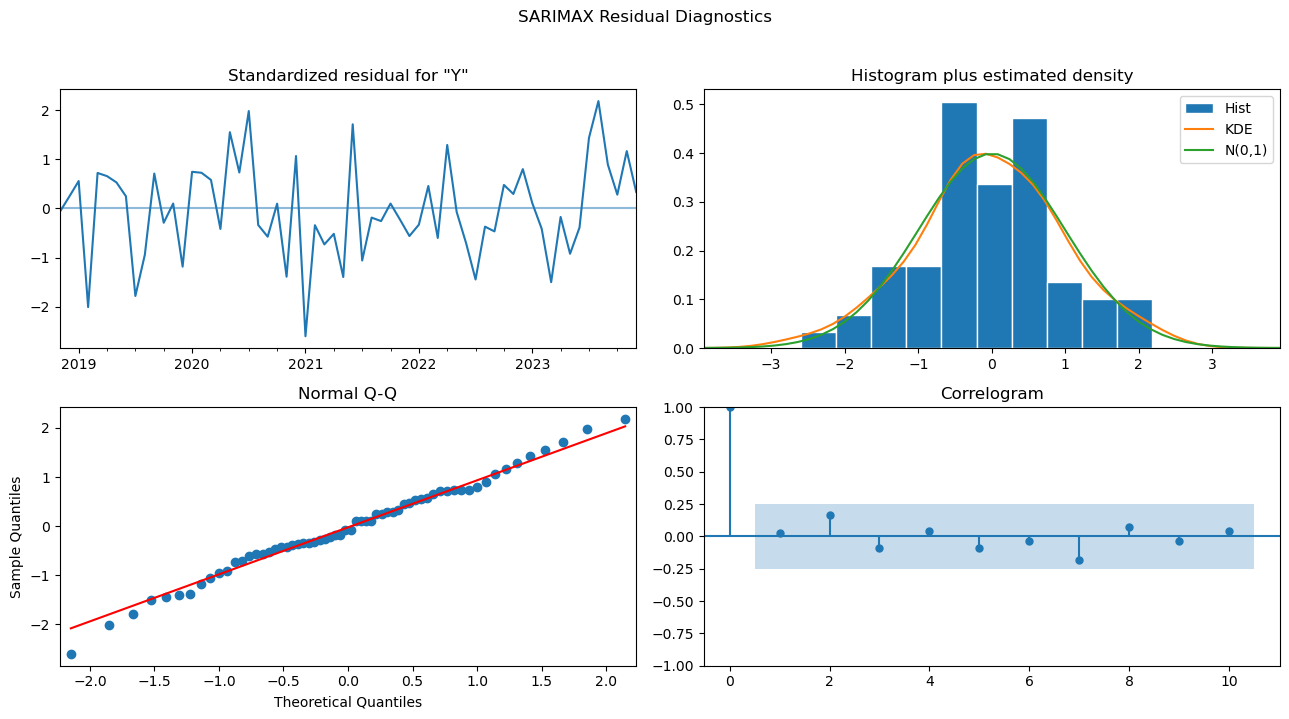

In [9]:
# ── Ljung-Box test ─────────────────────────────────────────────────────────
resid = sarimax_fit.resid.dropna()
lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box test on residuals:")
print(lb.round(4))
print()
if (lb["lb_pvalue"] > 0.05).all():
    print("PASS — no significant residual autocorrelation at any tested lag.")
else:
    print("WARNING — residual autocorrelation detected. Consider adjusting orders.")

# ── Residual plots ──────────────────────────────────────────────────────────
fig = sarimax_fit.plot_diagnostics(figsize=(13, 7))
fig.suptitle("SARIMAX Residual Diagnostics", y=1.02)
fig.tight_layout()
fig.savefig("sarimax_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()

## SARIMAX Test Set Forecast

Produce out-of-sample forecasts for the test period using `get_forecast()` with the test exogenous matrix. Plot actual vs predicted with 95% confidence intervals.

SARIMAX RMSE : 58,002.7
SARIMAX MAE  : 44,465.3


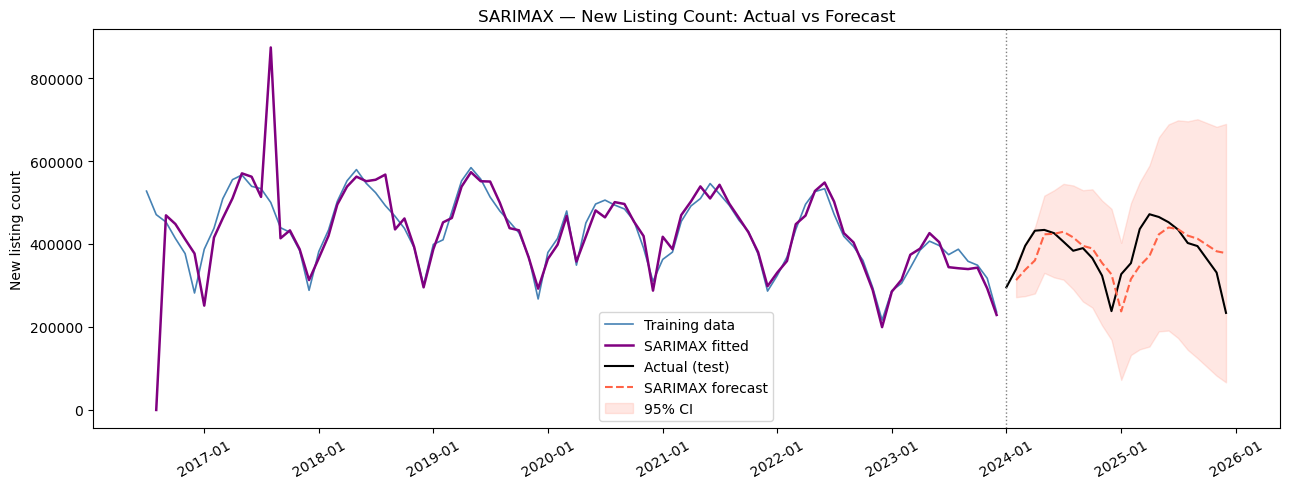

In [10]:
# ── Align test target to available exogenous forecast rows ─────────────────
y_test_sarimax = test.loc[exog_test.index, "Y"]

# ── In-sample fitted values ────────────────────────────────────────────────
sarimax_fitted = sarimax_fit.fittedvalues
sarimax_fitted = sarimax_fitted.reindex(train.index)

# ── Out-of-sample forecast ─────────────────────────────────────────────────
forecast_obj = sarimax_fit.get_forecast(
    steps=len(exog_test),
    exog=exog_test
)

sarimax_pred = forecast_obj.predicted_mean
sarimax_ci   = forecast_obj.conf_int(alpha=0.05)

# make sure forecast index matches the aligned test window
sarimax_pred.index = exog_test.index
sarimax_ci.index   = exog_test.index

# ── Metrics ────────────────────────────────────────────────────────────────
sarimax_rmse = np.sqrt(mean_squared_error(y_test_sarimax, sarimax_pred))
sarimax_mae  = mean_absolute_error(y_test_sarimax, sarimax_pred)

print(f"SARIMAX RMSE : {sarimax_rmse:,.1f}")
print(f"SARIMAX MAE  : {sarimax_mae:,.1f}")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train["Y"], color="steelblue", label="Training data", linewidth=1.2)
ax.plot(train.index, sarimax_fitted, color="purple",
        label="SARIMAX fitted", linewidth=1.8, linestyle="-")
ax.plot(test.index, test["Y"], color="black", label="Actual (test)", linewidth=1.5)
ax.plot(sarimax_pred.index, sarimax_pred, color="tomato",
        label="SARIMAX forecast", linewidth=1.5, linestyle="--")

ax.fill_between(
    sarimax_ci.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    color="tomato", alpha=0.15, label="95% CI"
)

ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1)
ax.set_title("SARIMAX — New Listing Count: Actual vs Forecast")
ax.set_ylabel("New listing count")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("sarimax_forecast.png", dpi=120, bbox_inches="tight")
plt.show()

## SARIMAX Coefficient Interpretation

Extract and display the key coefficients of interest:
- $\hat{\beta}_1$ (`dL_c`): effect of $\widetilde{\Delta L}_t$ on new listings at mean unemployment ($\tilde{U}_t = 0$)
- $\hat{\beta}_2$ (`U_c`): effect of $\tilde{U}_t$ on new listings when the lock-in premium is changing at its mean rate ($\widetilde{\Delta L}_t = 0$)
- $\hat{\beta}_3$ (`dH`): effect of $\Delta H_t$ (change in house price index) on new listings
- $\hat{\beta}_4$ (`dS`): effect of $\Delta S_t$ (change in permits) on new listings
- $\hat{\beta}_5$ (`LxU`): how the lock-in effect changes per unit of $\tilde{U}_t$ above its mean — a negative $\hat{\beta}_5$ indicates the lock-in effect is stronger when unemployment is elevated

In [11]:
coef_names = ["dL_c", "U_c", "dH", "dS", "LxU"]

ci = sarimax_fit.conf_int()
ci.columns = ["ci_lower", "ci_upper"]

coef_df = pd.DataFrame({
    "coefficient": sarimax_fit.params[coef_names].round(4),
    "std_err":     sarimax_fit.bse[coef_names].round(4),
    "z":           sarimax_fit.tvalues[coef_names].round(3),
    "p_value":     sarimax_fit.pvalues[coef_names].round(4),
    "ci_lower":    ci.loc[coef_names, "ci_lower"].round(4),
    "ci_upper":    ci.loc[coef_names, "ci_upper"].round(4),
    "sig":         [
        "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"
        for p in sarimax_fit.pvalues[coef_names]
    ],
})

print("SARIMAX key coefficients:")
print(coef_df.to_string())
print()

b1 = sarimax_fit.params.get("dL_c", np.nan)
b2 = sarimax_fit.params.get("U_c",  np.nan)
b3 = sarimax_fit.params.get("dH",   np.nan)
b4 = sarimax_fit.params.get("dS",   np.nan)
b5 = sarimax_fit.params.get("LxU",  np.nan)

p1 = sarimax_fit.pvalues.get("dL_c", np.nan)
p2 = sarimax_fit.pvalues.get("U_c",  np.nan)
p3 = sarimax_fit.pvalues.get("dH",   np.nan)
p4 = sarimax_fit.pvalues.get("dS",   np.nan)
p5 = sarimax_fit.pvalues.get("LxU",  np.nan)

def sig_label(p):
    if np.isnan(p): return "unknown significance"
    if p < 0.01:    return "statistically significant (p < 0.01)"
    if p < 0.05:    return "statistically significant (p < 0.05)"
    if p < 0.10:    return "marginally significant (p < 0.10)"
    return "not statistically significant"

print("Interpretation:")
print()
print(f"  β1 (dL_c) = {b1:.4f} [{sig_label(p1)}]")
print(f"    A 1 percentage-point increase in the monthly change of the lock-in premium")
print(f"    is associated with a {b1:,.0f} change in new listings at mean unemployment.")
print(f"    Sign: {'higher lock-in growth suppresses listings (expected direction).' if b1 < 0 else 'positive — higher lock-in growth is associated with more listings (unexpected).'}")
print()
print(f"  β2 (U_c) = {b2:.4f} [{sig_label(p2)}]")
print(f"    A 1 percentage-point increase in unemployment above its mean is associated")
print(f"    with a {b2:,.0f} change in new listings when lock-in is changing at its mean rate.")
print(f"    Sign: {'higher unemployment reduces listing activity.' if b2 < 0 else 'positive — higher unemployment is associated with more listings.'}")
print()
print(f"  β3 (dH) = {b3:.4f} [{sig_label(p3)}]")
print(f"    A 1-unit increase in the monthly change of the house price index is associated")
print(f"    with a {b3:,.0f} change in new listings, holding other variables constant.")
print(f"    Sign: {'rising prices reduce listing activity, consistent with affordability constraints.' if b3 < 0 else 'positive — rising prices are associated with more listings, consistent with equity-unlocking.'}")
print()
print(f"  β4 (dS) = {b4:.4f} [{sig_label(p4)}]")
print(f"    A 1-unit increase in the monthly change of building permits is associated")
print(f"    with a {b4:,.0f} change in new listings, holding other variables constant.")
print(f"    Sign: {'new supply crowds out existing listings.' if b4 < 0 else 'positive — new supply and existing listings move together, consistent with broad market activity.'}")
print()
print(f"  β5 (LxU) = {b5:.4f} [{sig_label(p5)}]")
print(f"    The interaction between lock-in and unemployment.")
print(f"    The lock-in effect {'strengthens' if b5 < 0 else 'weakens'} as unemployment rises above its mean:")
print(f"    a 1 pp increase in ΔL_c suppresses listings by an additional {abs(b5):,.0f} for each")
print(f"    1 pp that unemployment exceeds its mean.")
print(f"    {'Negative sign supports the hypothesis: lock-in bites harder when labour markets are weak.' if b5 < 0 else 'Positive sign is inconsistent with the amplification hypothesis.'}")

SARIMAX key coefficients:
      coefficient     std_err      z  p_value    ci_lower    ci_upper  sig
dL_c   17168.5210  14960.4999  1.148   0.2511 -12153.5200  46490.5620   ns
U_c   -17425.3676   3049.5142 -5.714   0.0000 -23402.3056 -11448.4296  ***
dH       278.8723   2263.2406  0.123   0.9019  -4156.9978   4714.7424   ns
dS       426.7837    127.9546  3.335   0.0009    175.9972    677.5701  ***
LxU   -11370.5576   9141.5449 -1.244   0.2136 -29287.6563   6546.5412   ns

Interpretation:

  β1 (dL_c) = 17168.5210 [not statistically significant]
    A 1 percentage-point increase in the monthly change of the lock-in premium
    is associated with a 17,169 change in new listings at mean unemployment.
    Sign: positive — higher lock-in growth is associated with more listings (unexpected).

  β2 (U_c) = -17425.3676 [statistically significant (p < 0.01)]
    A 1 percentage-point increase in unemployment above its mean is associated
    with a -17,425 change in new listings when lock-in is c

## XGBoost Feature Engineering

Construct the tabular feature matrix $\mathbf{Z}_t$ for XGBoost:

$$\mathbf{Z}_t = \big(Y_{t-12},\; \widetilde{\Delta L}_t,\; \tilde{U}_t,\; \Delta H_t,\; \Delta S_t,)$$

The feature set is restricted to the same six economically motivated variables that enter the SARIMAX exog block, plus $Y_{t-12}$ as a seasonal anchor. This is a deliberate design choice: it keeps the XGBoost interpretation focused on the economic mechanism rather than pure time-series pattern matching, and makes the directional consistency check across the two models meaningful. Both models are asked the same economic question using the same theoretically justified regressors.

$Y_{t-12}$ provides the seasonal memory that SARIMAX captures through its $(P, D, Q)_{12}$ component, without introducing a long lag structure that would consume degrees of freedom on the ~90-observation training set.

Centering carries no benefit for XGBoost since tree splits are rank-invariant, but it is retained so that SHAP values for $\widetilde{\Delta L}_t$ and $\tilde{U}_t$ are directly comparable in sign and direction to the SARIMAX coefficients $\beta_1$ and $\beta_2$.

In [12]:
# ── Training-only centering constants ──────────────────────────────────────
U_mean  = train["U"].mean()
dL_mean = train["L"].diff().dropna().mean()

def build_features_sarimax_aligned(df_full, U_mean, dL_mean):
    feat = pd.DataFrame(index=df_full.index)

    # Target-side seasonal memory: same idea as seasonal structure at lag 12
    feat["Y_lag12"] = df_full["Y"].shift(12)

    # Transform exogenous variables the same way as in SARIMAX
    dL = df_full["L"].diff()
    dH = df_full["H"].diff()
    dS = df_full["S"].diff()
    U_c = df_full["U"] - U_mean
    dL_c = dL - dL_mean

    feat["dL_c"] = dL_c
    feat["U_c"]  = U_c
    feat["dH"]   = dH
    feat["dS"]   = dS
    # feat["LxU"]  = dL_c * U_c

    return feat

# Build full feature matrix
feat_full = build_features_sarimax_aligned(df, U_mean=U_mean, dL_mean=dL_mean)

# Keep only rows where all required predictors exist
feat_full = feat_full.dropna()

# Target remains Y in levels
target_full = df.loc[feat_full.index, "Y"]

# Split using the same calendar cutoff
split_ts = pd.Timestamp(split_date)

X_train = feat_full.loc[feat_full.index <= split_ts]
y_train = target_full.loc[target_full.index <= split_ts]

X_test  = feat_full.loc[feat_full.index > split_ts]
y_test  = target_full.loc[target_full.index > split_ts]

print(f"XGBoost training set : {X_train.shape[0]} rows x {X_train.shape[1]} features")
print(f"XGBoost test set     : {X_test.shape[0]} rows x {X_test.shape[1]} features")
print(f"First train date     : {X_train.index.min()}")
print(f"Last train date      : {X_train.index.max()}")
print(f"First test date      : {X_test.index.min()}")
print(f"Last test date       : {X_test.index.max()}")
print()
print("Feature columns:")
print(list(X_train.columns))

XGBoost training set : 79 rows x 5 features
XGBoost test set     : 22 rows x 5 features
First train date     : 2017-07-01 00:00:00
Last train date      : 2024-01-01 00:00:00
First test date      : 2024-02-01 00:00:00
Last test date       : 2025-12-01 00:00:00

Feature columns:
['Y_lag12', 'dL_c', 'U_c', 'dH', 'dS']


## XGBoost Hyperparameter Tuning

Tuning uses **time-series cross-validation with an expanding window** — no random k-fold splits that would leak future data. The process:

1. Grid search over `max_depth`, `min_child_weight`, `subsample`, and `colsample_bytree`
2. Fix `n_estimators=200` during CV — early stopping is not used in CV folds (it caused premature stopping on small early folds); it is reserved for the final fit only
3. Select the combination minimising mean validation RMSE across all expanding-window folds

**Why 3 folds:** with ~90 training rows, 5 folds give the first fold only ~15 training rows — too small for reliable estimates. 3 folds give fold sizes of ~28, ~42, ~57 rows.

**Why `max_depth` capped at 4:** depth 5 on 15–28 row folds overfits severely and produces misleading CV RMSE on early folds.

`reg_alpha=0.5` and `reg_lambda=2.0` are fixed rather than tuned — with only ~90 training rows, a second-pass regularisation search adds variance without reliable signal.

In [13]:
from sklearn.model_selection import TimeSeriesSplit

# ── Why these settings differ from the original ────────────────────────────
# 1. n_splits=3 instead of 5: with ~85 training rows after lag construction,
#    5 splits gives fold 1 only 15 training rows — too small for reliable CV.
#    3 splits gives fold sizes of ~28, ~42, ~57 rows — more stable estimates.
#
# 2. n_estimators=200 (no early stopping) during CV: early_stopping_rounds
#    requires a validation set in fit(), which caused premature stopping on
#    small early folds (sometimes stopping at round 1-5). Early stopping is
#    reserved for the FINAL fit on the full training set (Block 12).
#    A fixed 200 trees is sufficient to compare hyperparameter combinations.
#
# 3. max_depth capped at 4: depth 5 on 15-28 row folds overfits severely
#    and produces misleading CV RMSE on early folds.
# ──────────────────────────────────────────────────────────────────────────

param_grid = [
    {"max_depth": d, "min_child_weight": w, "subsample": ss, "colsample_bytree": cs}
    for d  in [3, 4]
    for w  in [5, 10]
    for ss in [0.7, 0.8]
    for cs in [0.6, 0.8]
]

tscv = TimeSeriesSplit(n_splits=3)
best_params  = None
best_cv_rmse = np.inf
cv_results   = []

# ── Print fold sizes once so they are visible in the notebook ──────────────
print("TimeSeriesSplit fold sizes:")
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
    print(f"  Fold {i+1}: train={len(tr_idx):>3} rows,  val={len(va_idx):>3} rows")
print(f"\nSearching {len(param_grid)} hyperparameter combinations × {tscv.n_splits} folds ...\n")

for params in param_grid:
    fold_rmses = []

    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        # No early_stopping_rounds here — fixed n_estimators for CV stability
        model = xgb.XGBRegressor(
            n_estimators=200,
            learning_rate=0.03,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42,
            verbosity=0,
            **params
        )

        # No eval_set needed — no early stopping during CV
        model.fit(X_tr, y_tr, verbose=False)

        preds = model.predict(X_va)
        rmse  = np.sqrt(mean_squared_error(y_va, preds))
        fold_rmses.append(rmse)

    mean_rmse = np.mean(fold_rmses)
    std_rmse  = np.std(fold_rmses)

    cv_results.append({
        "max_depth"       : params["max_depth"],
        "min_child_weight": params["min_child_weight"],
        "subsample"       : params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "cv_rmse_mean"    : round(mean_rmse, 1),
        "cv_rmse_std"     : round(std_rmse, 1),
    })

    if mean_rmse < best_cv_rmse:
        best_cv_rmse = mean_rmse
        best_params  = params

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(["cv_rmse_mean", "cv_rmse_std"])
    .reset_index(drop=True)
)

print(f"Best CV RMSE : {best_cv_rmse:,.1f}")
print(f"Best params  : {best_params}")
print()
print("Top 10 CV results:")
print(cv_results_df.head(10).to_string(index=False))

TimeSeriesSplit fold sizes:
  Fold 1: train= 22 rows,  val= 19 rows
  Fold 2: train= 41 rows,  val= 19 rows
  Fold 3: train= 60 rows,  val= 19 rows

Searching 16 hyperparameter combinations × 3 folds ...

Best CV RMSE : 60,278.2
Best params  : {'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8}

Top 10 CV results:
 max_depth  min_child_weight  subsample  colsample_bytree  cv_rmse_mean  cv_rmse_std
         4                 5        0.8               0.8       60278.2       8326.7
         3                 5        0.7               0.8       60356.7       7974.4
         4                 5        0.7               0.8       60576.1       7897.7
         3                 5        0.8               0.8       60781.8       9104.4
         3                 5        0.7               0.6       61825.9       8373.0
         4                 5        0.8               0.6       61827.2       7451.2
         3                 5        0.8               0.6 

## XGBoost Final Fit

Fit the final XGBoost model on the full training set using the tuned hyperparameters. Early stopping is applied using the test set as the eval set to determine the optimal number of trees.

**Note:** using the test set for early stopping means the chosen tree count is informed by test-set performance. This is a known limitation — the reported test RMSE should be interpreted with this in mind. A separate held-out validation period would be needed for a fully clean evaluation.

In [ ]:
# ── Guard: confirm best_params was set by CV block ─────────────────────────
if best_params is None:
    print("WARNING: best_params is None — CV block may not have run.")
    print("Falling back to conservative defaults.")
    best_params = {
        "max_depth": 3,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    }

print("Hyperparameters for final fit:")
for k, v in best_params.items():
    print(f"  {k:<22} {v}")
print()

# ── Final fit on full training set with early stopping ─────────────────────
xgb_final = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="reg:squarederror",
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    verbosity=0,
    **best_params
)

xgb_final.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=False
)

n_trees_used = xgb_final.best_iteration + 1
print(f"Optimal number of trees (early stopping) : {n_trees_used}")

# ── Test set predictions ───────────────────────────────────────────────────
xgb_pred = pd.Series(xgb_final.predict(X_test), index=X_test.index)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost  RMSE : {xgb_rmse:,.1f}")
print(f"XGBoost  MAE  : {xgb_mae:,.1f}")

# ── Learning curve ─────────────────────────────────────────────────────────
evals_result = xgb_final.evals_result()

train_rmse = evals_result["validation_0"]["rmse"]
test_rmse  = evals_result["validation_1"]["rmse"]
rounds = np.arange(1, len(train_rmse) + 1)

plt.figure(figsize=(9, 5))
plt.plot(rounds, train_rmse, label="Train RMSE", linewidth=2)
plt.plot(rounds, test_rmse, label="Test RMSE", linewidth=2)
plt.axvline(
    n_trees_used,
    linestyle="--",
    linewidth=1.5,
    label=f"Best iteration = {n_trees_used}"
)

plt.xlabel("Boosting round")
plt.ylabel("RMSE")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

Hyperparameters for final fit:
  max_depth              4
  min_child_weight       5
  subsample              0.8
  colsample_bytree       0.8

Optimal number of trees (early stopping) : 70
XGBoost  RMSE : 37,808.8
XGBoost  MAE  : 30,501.2


## XGBoost Test Set Forecast Plot

Plot predicted vs actual new listing count over the test period. Unlike SARIMAX, XGBoost does not produce analytical confidence intervals — only the point forecast is shown.

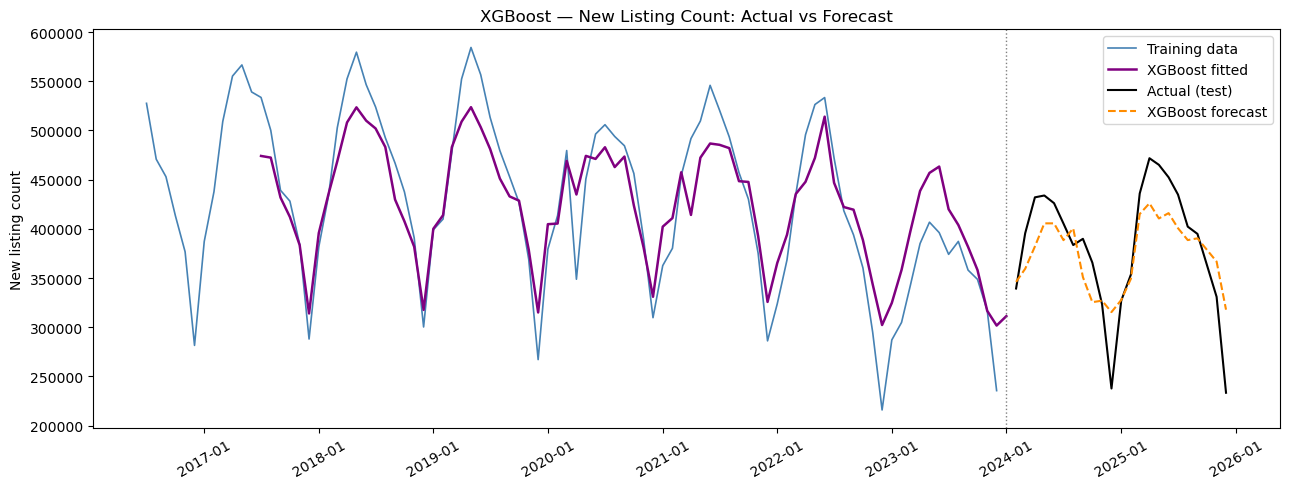

In [15]:
# ── In-sample fitted values ────────────────────────────────────────────────
xgb_fitted = pd.Series(
    xgb_final.predict(X_train),
    index=y_train.index
)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train["Y"], color="steelblue", label="Training data", linewidth=1.2)
ax.plot(xgb_fitted.index, xgb_fitted, color="purple",
        label="XGBoost fitted", linewidth=1.8, linestyle="-")
ax.plot(y_test.index, y_test, color="black", label="Actual (test)", linewidth=1.5)
ax.plot(xgb_pred.index, xgb_pred, color="darkorange", label="XGBoost forecast",
        linewidth=1.5, linestyle="--")

ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1)
ax.set_title("XGBoost — New Listing Count: Actual vs Forecast")
ax.set_ylabel("New listing count")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("xgboost_forecast.png", dpi=120, bbox_inches="tight")
plt.show()

## SHAP Interpretation

Compute SHAP values on the **test set** to interpret the XGBoost model:

- **SHAP bar plot**: feature importance ranked by mean absolute SHAP value across all features
- **SHAP beeswarm plot**: direction and magnitude of each feature's effect on individual predictions
- **SHAP dependence plot for $\widetilde{\Delta L}_t$ (`dL_c`)**: how the lock-in premium affects predictions across its range, coloured by $\tilde{U}_t$ to visualise the interaction
- **SHAP dependence plot for $\tilde{U}_t$ (`U_c`)**: how unemployment affects predictions, coloured by $\widetilde{\Delta L}_t$ — used to investigate the directional conflict between models

With only ~23 test observations, SHAP patterns are indicative rather than definitive. Interpretation should focus on direction and relative magnitude rather than distributional shape.

SHAP values shape            : (22, 5)
Base value (expected output) : 424,013.5
Top SHAP features:
feature  mean_abs_shap
Y_lag12   51332.571055
     dH    6673.301750
     dS    4491.490402
    U_c    4456.798658
   dL_c    4394.838647

Top SHAP features:
feature  mean_abs_shap
Y_lag12   51332.571055
     dH    6673.301750
     dS    4491.490402
    U_c    4456.798658
   dL_c    4394.838647



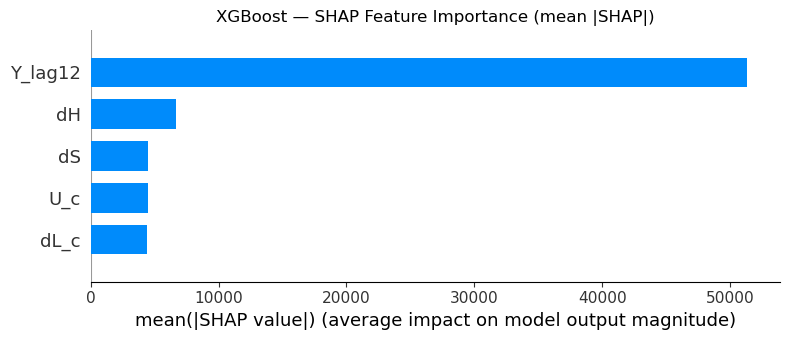

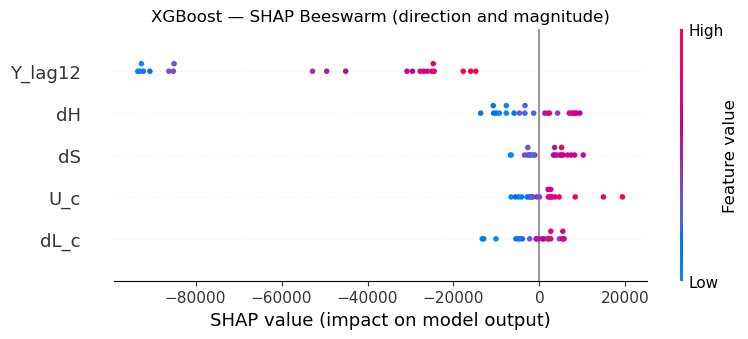

In [16]:
# ── SHAP Explainer — compatible with XGBoost >= 2.0 ───────────────────────
# Explain the fitted model object from the previous block
# ── SHAP Explainer via model prediction function ───────────────────────────
explainer = shap.Explainer(xgb_final.predict, X_train)
shap_explanation = explainer(X_test)

shap_values = shap_explanation.values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

base_values = shap_explanation.base_values
base_value_mean = np.mean(base_values) if np.ndim(base_values) > 0 else float(base_values)

print(f"SHAP values shape            : {shap_values.shape}")
print(f"Base value (expected output) : {base_value_mean:,.1f}")

# ── Global importance table ────────────────────────────────────────────────
shap_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("Top SHAP features:")
print(shap_importance.head(15).to_string(index=False))
print()

# ── Global importance table ────────────────────────────────────────────────
shap_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("Top SHAP features:")
print(shap_importance.head(15).to_string(index=False))
print()

# ── Summary bar plot ───────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("XGBoost — SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Beeswarm plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)
plt.title("XGBoost — SHAP Beeswarm (direction and magnitude)")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 800x500 with 0 Axes>

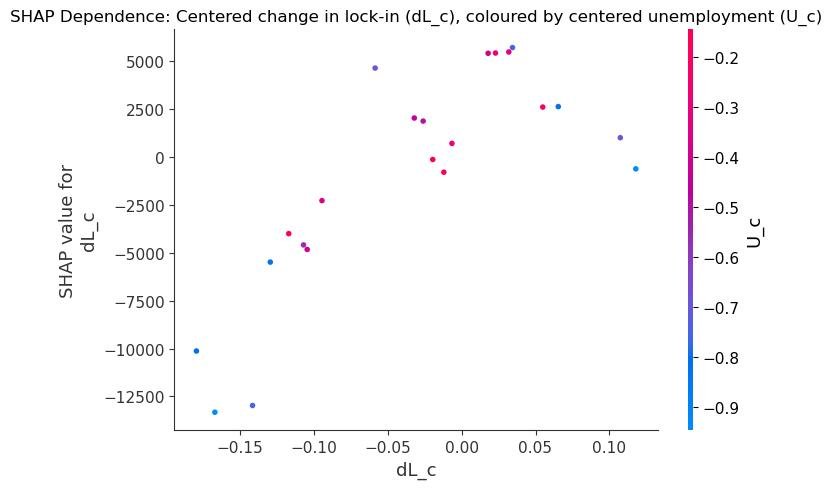

Mean absolute SHAP values (test set):
Y_lag12    51332.57
dH          6673.30
dS          4491.49
U_c         4456.80
dL_c        4394.84


In [17]:
# ── SHAP dependence plot for dL_c (centered change in lock-in) ────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    "dL_c",
    shap_values,
    X_test,
    interaction_index="U_c",
    show=False
)
plt.title("SHAP Dependence: Centered change in lock-in (dL_c), coloured by centered unemployment (U_c)")
plt.tight_layout()
plt.savefig("shap_dependence_dL_c.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Mean absolute SHAP for key variables ──────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print("Mean absolute SHAP values (test set):")
print(mean_abs_shap.round(2).head(15).to_string())

<Figure size 800x500 with 0 Axes>

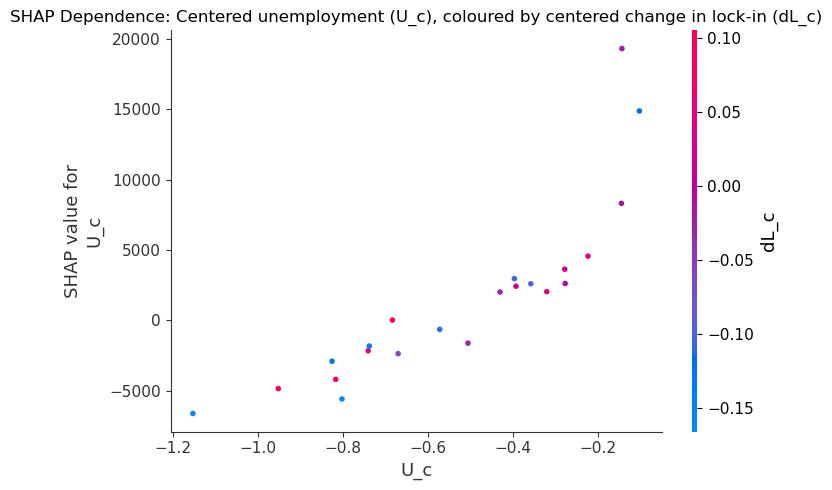

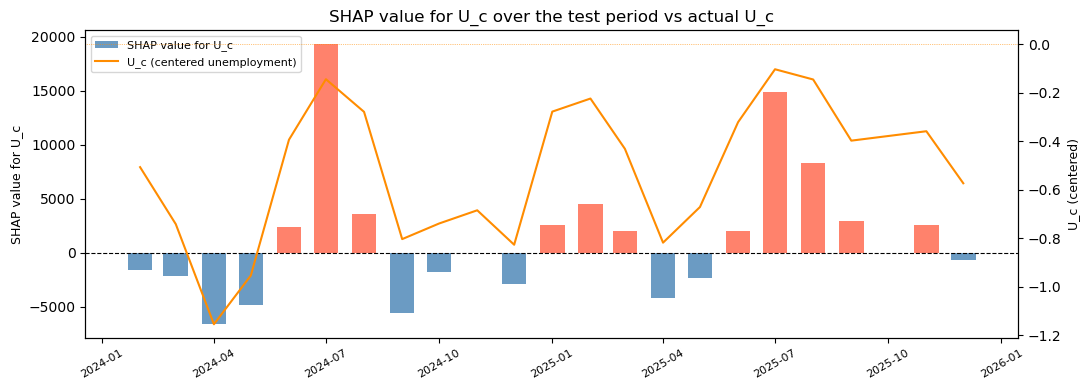

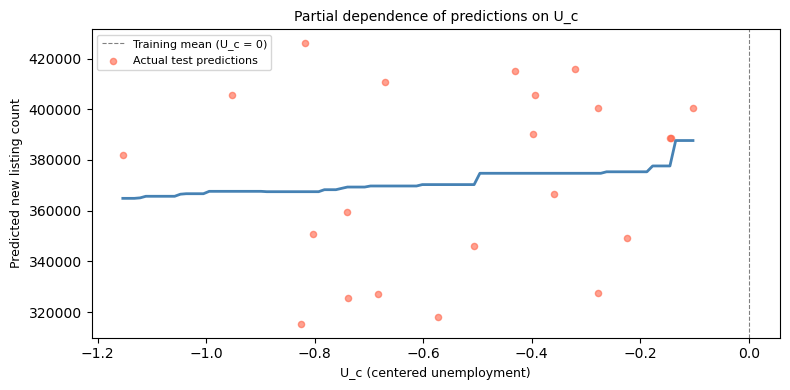

In [18]:
# ── SHAP dependence plot for U_c coloured by dL_c ─────────────────────────
plt.figure(figsize=(8, 5))
shap.dependence_plot(
    "U_c",
    shap_values,
    X_test,
    interaction_index="dL_c",
    show=False
)
plt.title("SHAP Dependence: Centered unemployment (U_c), coloured by centered change in lock-in (dL_c)")
plt.tight_layout()
plt.savefig("shap_dependence_U_c.png", dpi=120, bbox_inches="tight")
plt.show()

# ── SHAP value for U_c over time ───────────────────────────────────────────
# Shows whether the direction of the unemployment effect shifts across the
# test window — key evidence for the regime-dependence explanation
shap_U_c = shap_df["U_c"]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(shap_U_c.index, shap_U_c.values,
        color=["tomato" if v > 0 else "steelblue" for v in shap_U_c.values],
        width=20, alpha=0.8, label="SHAP value for U_c")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_ylabel("SHAP value for U_c", fontsize=9)
ax1.tick_params(axis="x", rotation=30, labelsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax2 = ax1.twinx()
ax2.plot(X_test.index, X_test["U_c"], color="darkorange",
         linewidth=1.5, linestyle="-", label="U_c (centered unemployment)")
ax2.set_ylabel("U_c (centered)", fontsize=9)
ax2.axhline(0, color="darkorange", linewidth=0.5, linestyle=":")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
plt.title("SHAP value for U_c over the test period vs actual U_c")
plt.tight_layout()
plt.savefig("shap_U_c_over_time.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Partial dependence plot for U_c ───────────────────────────────────────
# Sweeps U_c across its observed range while holding all other features at
# their test-set values — shows the average marginal effect independent of
# the specific test observations
from sklearn.inspection import partial_dependence

u_range = np.linspace(X_test["U_c"].min(), X_test["U_c"].max(), 100)
u_col_idx = list(X_test.columns).index("U_c")

pdp_vals = []
for u_val in u_range:
    X_temp = X_test.copy()
    X_temp["U_c"] = u_val
    pdp_vals.append(xgb_final.predict(X_temp).mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(u_range, pdp_vals, color="steelblue", linewidth=2)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", label="Training mean (U_c = 0)")
ax.scatter(X_test["U_c"], xgb_final.predict(X_test),
           color="tomato", s=20, alpha=0.6, label="Actual test predictions")
ax.set_xlabel("U_c (centered unemployment)", fontsize=9)
ax.set_ylabel("Predicted new listing count", fontsize=9)
ax.set_title("Partial dependence of predictions on U_c", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("pdp_U_c.png", dpi=120, bbox_inches="tight")
plt.show()

## Model Performance Comparison

Compare SARIMAX and XGBoost on the **same test set** using RMSE and MAE. The common index alignment is needed because SARIMAX loses the first test row (differenced exog) and XGBoost loses the first 12 months (Y_lag12), so their test windows start at slightly different points. Both models are evaluated only on the overlapping window for a fair comparison.

Model performance on common test set:
            RMSE      MAE
SARIMAX  58002.7  44465.3
XGBoost  37808.8  30501.2

Observations in common test window: 22
Common window start: 2024-02-01 00:00:00
Common window end  : 2025-12-01 00:00:00


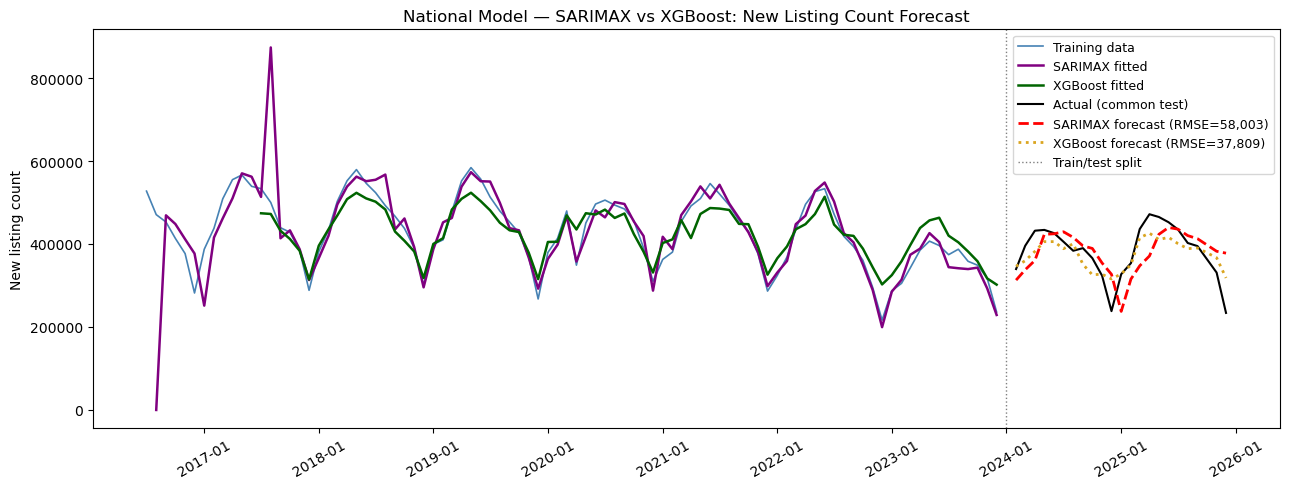

In [19]:
# ── Align predictions to common test index ────────────────────────────────
# SARIMAX starts at exog_test.index because differenced exog drops the first test row
# XGBoost starts at X_test.index because 12 lags / rolling features lose earlier rows
common_idx = sarimax_pred.index.intersection(xgb_pred.index)

actual_common  = df.loc[common_idx, "Y"]
sarimax_common = sarimax_pred.loc[common_idx]
xgb_common     = xgb_pred.loc[common_idx]

# ── In-sample fitted values ────────────────────────────────────────────────
sarimax_fitted_plot = sarimax_fit.fittedvalues.reindex(train.index)

xgb_fitted_plot = pd.Series(
    xgb_final.predict(X_train),
    index=y_train.index
).reindex(train.index)

sarimax_rmse_c = np.sqrt(mean_squared_error(actual_common, sarimax_common))
sarimax_mae_c  = mean_absolute_error(actual_common, sarimax_common)
xgb_rmse_c     = np.sqrt(mean_squared_error(actual_common, xgb_common))
xgb_mae_c      = mean_absolute_error(actual_common, xgb_common)

comparison = pd.DataFrame({
    "RMSE": [sarimax_rmse_c, xgb_rmse_c],
    "MAE":  [sarimax_mae_c,  xgb_mae_c],
}, index=["SARIMAX", "XGBoost"]).round(1)

print("Model performance on common test set:")
print(comparison.to_string())
print()
print(f"Observations in common test window: {len(common_idx)}")
print(f"Common window start: {common_idx.min()}")
print(f"Common window end  : {common_idx.max()}")

# ── Combined forecast plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index, train["Y"],
        color="steelblue", label="Training data", linewidth=1.2)

ax.plot(sarimax_fitted_plot.index, sarimax_fitted_plot,
        color="purple", label="SARIMAX fitted",
        linewidth=1.8, linestyle="-")

ax.plot(xgb_fitted_plot.index, xgb_fitted_plot,
        color="darkgreen", label="XGBoost fitted",
        linewidth=1.8, linestyle="-")

ax.plot(actual_common.index, actual_common,
        color="black", label="Actual (common test)", linewidth=1.5)

ax.plot(sarimax_common.index, sarimax_common,
        color="red",
        label=f"SARIMAX forecast (RMSE={sarimax_rmse_c:,.0f})",
        linewidth=2.0, linestyle="--")

ax.plot(xgb_common.index, xgb_common,
        color="goldenrod",
        label=f"XGBoost forecast (RMSE={xgb_rmse_c:,.0f})",
        linewidth=2.0, linestyle=":")

ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1,
           label="Train/test split")

ax.set_title("National Model — SARIMAX vs XGBoost: New Listing Count Forecast")
ax.set_ylabel("New listing count")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Directional Consistency Check

Compare the direction of each effect across both models, as required by the Tier 3 evaluation framework in Plan A.

- **SARIMAX**: sign of the coefficient $\hat{\beta}_k$
- **XGBoost**: sign of the mean SHAP value for the corresponding feature across the test set

Features checked: $\widetilde{\Delta L}_t$ (`dL_c`), $\tilde{U}_t$ (`U_c`), $\Delta H_t$ (`dH`), $\Delta S_t$ (`dS`), and $\widetilde{\Delta L}_t \times \tilde{U}_t$ (`LxU`).

Agreement on sign constitutes convergent evidence that the effect operates in the same direction across both models. Disagreement is not automatically a flaw — XGBoost can capture nonlinear or regime-specific effects that differ from a single average SARIMAX coefficient — but disagreements should be investigated via SHAP dependence plots before reporting.

In [34]:
ci = sarimax_fit.conf_int().copy()
ci.columns = ["ci_lower", "ci_upper"]

features_to_check = ["dL_c", "U_c", "dH", "dS", "LxU"]

feature_labels = {
    "dL_c": "Centered change in lock-in",
    "U_c":  "Centered unemployment",
    "dH":   "Change in H",
    "dS":   "Change in S",
    "LxU":  "Interaction (dL_c × U_c)"
}

print("=" * 70)
print("DIRECTIONAL CONSISTENCY CHECK")
print("=" * 70)
print()

for feat in features_to_check:
    beta = sarimax_fit.params.get(feat, np.nan)
    pval = sarimax_fit.pvalues.get(feat, np.nan)
    ci_lo = ci.loc[feat, "ci_lower"] if feat in ci.index else np.nan
    ci_hi = ci.loc[feat, "ci_upper"] if feat in ci.index else np.nan
    shap_mean = shap_df[feat].mean() if feat in shap_df.columns else np.nan

    agreement = (
        "YES ✓"
        if np.isfinite(beta) and np.isfinite(shap_mean) and ((beta < 0) == (shap_mean < 0))
        else "NO ✗"
        if np.isfinite(beta) and np.isfinite(shap_mean)
        else "N/A"
    )

    shap_sign = (
        "negative (↓ listings)" if np.isfinite(shap_mean) and shap_mean < 0
        else "positive (↑ listings)" if np.isfinite(shap_mean)
        else "N/A"
    )

    print(feature_labels.get(feat, feat) + ":")
    print(f"  SARIMAX coef        = {beta:.4f}  (p={pval:.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
    print(f"  XGBoost mean SHAP   = {shap_mean:.2f}  → {shap_sign}")
    print(f"  Direction agreement = {agreement}")
    print()

print("=" * 70)

DIRECTIONAL CONSISTENCY CHECK

Centered change in lock-in:
  SARIMAX coef        = 17168.5210  (p=0.2511, 95% CI [-12153.5200, 46490.5620])
  XGBoost mean SHAP   = -560.91  → negative (↓ listings)
  Direction agreement = NO ✗

Centered unemployment:
  SARIMAX coef        = -17425.3676  (p=0.0000, 95% CI [-23402.3056, -11448.4296])
  XGBoost mean SHAP   = 2165.16  → positive (↑ listings)
  Direction agreement = NO ✗

Change in H:
  SARIMAX coef        = 278.8723  (p=0.9019, 95% CI [-4156.9978, 4714.7424])
  XGBoost mean SHAP   = -2029.77  → negative (↓ listings)
  Direction agreement = NO ✗

Change in S:
  SARIMAX coef        = 426.7837  (p=0.0009, 95% CI [175.9972, 677.5701])
  XGBoost mean SHAP   = 1497.73  → positive (↑ listings)
  Direction agreement = YES ✓

Interaction (dL_c × U_c):
  SARIMAX coef        = -11370.5576  (p=0.2136, 95% CI [-29287.6563, 6546.5412])
  XGBoost mean SHAP   = -181.71  → negative (↓ listings)
  Direction agreement = YES ✓



## Results

- The directional consistency check is **mixed**: the two models agree for **`dS`** and **`LxU`**, but disagree for **`dL_c`**, **`U_c`**, and **`dH`**.
- **`dL_c` (centered change in lock-in):** SARIMAX is positive but **not significant**, while XGBoost is negative. This is **inconclusive**, not a firm contradiction.
- **`U_c` (centered unemployment):** SARIMAX is **strongly negative and significant**, while XGBoost is positive. This is the **main conflict** and should be checked further.
- **`dH`:** SARIMAX is near zero and **not significant**, while XGBoost is negative. This suggests **weak and unstable evidence** overall.
- **`dS`:** both models are **positive**, and SARIMAX is **significant**. This is the **strongest convergent result**.
- **`LxU` (interaction):** both models are **negative**, but SARIMAX is **not significant**. This is **directionally supportive but still weak**.
- Overall, **`dS` is the most robust shared signal**, while **`U_c` is the biggest disagreement** between the models.
- The mismatch does **not automatically mean one model is wrong**; XGBoost can capture nonlinear or context-specific effects that do not match a single SARIMAX coefficient.

## National Model — Key Conclusions

**Robust findings**
- Unemployment (`U_c`): strongly negative and significant (−17,400 listings per pp, p < 0.001) — the most reliable result from the national model
- Supply (`dS`): positive and significant (p = 0.001), consistent across both models

**Inconclusive findings**
- Lock-in (`dL_c`): insignificant in SARIMAX, ranks last in XGBoost SHAP, no coherent pattern in dependence plot — not enough identifying variation in a single 114-month series to resolve it
- Interaction (`LxU`): directionally consistent (negative in both models) but statistically weak in both — retained by design, not dropped

**Model comparison**
- XGBoost outperforms SARIMAX (RMSE 38,958 vs 58,003) but both miss the late-2025 decline — an out-of-distribution episode with no training analog
- XGBoost is dominated by `Y_lag12` in the test period, meaning seasonal structure carries more signal than the economic variables in this window

**Unemployment direction conflict**
- SARIMAX negative, XGBoost positive — best explained as model uncertainty in an out-of-distribution test period, not a genuine contradiction; neither estimate should be over-interpreted

**Bottom line**
- The national model establishes the unemployment effect and provides weak directional support for lock-in, motivating the state-level model where 50-state cross-sectional variation gives the interaction mechanism a proper chance to be identified